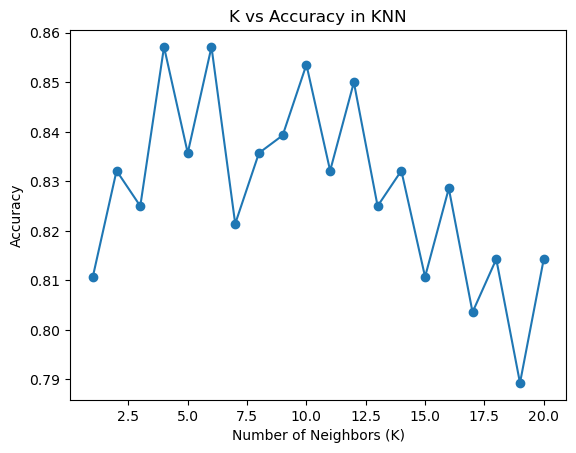

Accuracy: 0.8357142857142857

Confusion Matrix:
 [[ 30   0  16]
 [  0  49  24]
 [  2   4 155]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.65      0.77        46
           1       0.92      0.67      0.78        73
           2       0.79      0.96      0.87       161

    accuracy                           0.84       280
   macro avg       0.89      0.76      0.81       280
weighted avg       0.85      0.84      0.83       280



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("personal_carbon_footprint_behavior.csv")

df = df.drop("user_id", axis=1)

categorical_cols = ['day_type', 'transport_mode', 'food_type', 'carbon_impact_level']

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop("carbon_impact_level", axis=1)
y = df["carbon_impact_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.figure()
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy in KNN")
plt.show()

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))